In [13]:
import pandas as pd 
import numpy as np

In [14]:
pd.read_csv ('canais_venda.csv', sep=';')
pd.read_csv ('clientes.concat.csv', sep=';')
pd.read_csv ('funcionarios.concat.csv', sep=';')
pd.read_csv ('reservas.concat.corrigido.csv', sep=';')
pd.read_csv ('tipos_quarto.concat.csv', sep=';')
pd.read_csv ('unidades.concat.csv', sep=';')

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel(estrelas),num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5,75


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns



In [16]:
df_reservas = pd.read_csv('reservas.concat.corrigido.csv', sep=';')
df_tipos_quarto = pd.read_csv('tipos_quarto.concat.csv', sep=';')
df_unidades = pd.read_csv('unidades.concat.csv', sep=';')

In [17]:
# 1. Cruzamento de Dados
# Anexando o valor da diária base na tabela de reservas
df_merged = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']], on='id_tipo_quarto', how='left')

In [18]:
# Anexando o nome da unidade para facilitar a visualização no gráfico
df_merged = df_merged.merge(df_unidades[['id_unidade', 'nome_unidade', 'regiao']], on='id_unidade', how='left')

In [19]:
# 2. Cálculo do Faturamento da Reserva (Receita Bruta)
df_merged['faturamento_reserva'] = df_merged['qtd_diarias'] * df_merged['valor_diaria_base']

In [20]:
# 3. Agrupamento: Faturamento Total por Unidade
faturamento_unidade = df_merged.groupby('nome_unidade')['faturamento_reserva'].sum().sort_values(ascending=False).reset_index()

In [21]:
# 4. Agrupamento: Valor Médio da Diária por Unidade
ticket_medio_unidade = df_merged.groupby('nome_unidade')['valor_diaria_base'].mean().sort_values(ascending=False).reset_index()


C:\Users\Robert\AppData\Local\Temp\ipykernel_14628\3426007479.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=faturamento_unidade, x='faturamento_reserva', y='nome_unidade', ax=axes[0], palette='viridis')
C:\Users\Robert\AppData\Local\Temp\ipykernel_14628\3426007479.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ticket_medio_unidade, x='valor_diaria_base', y='nome_unidade', ax=axes[1], palette='magma')


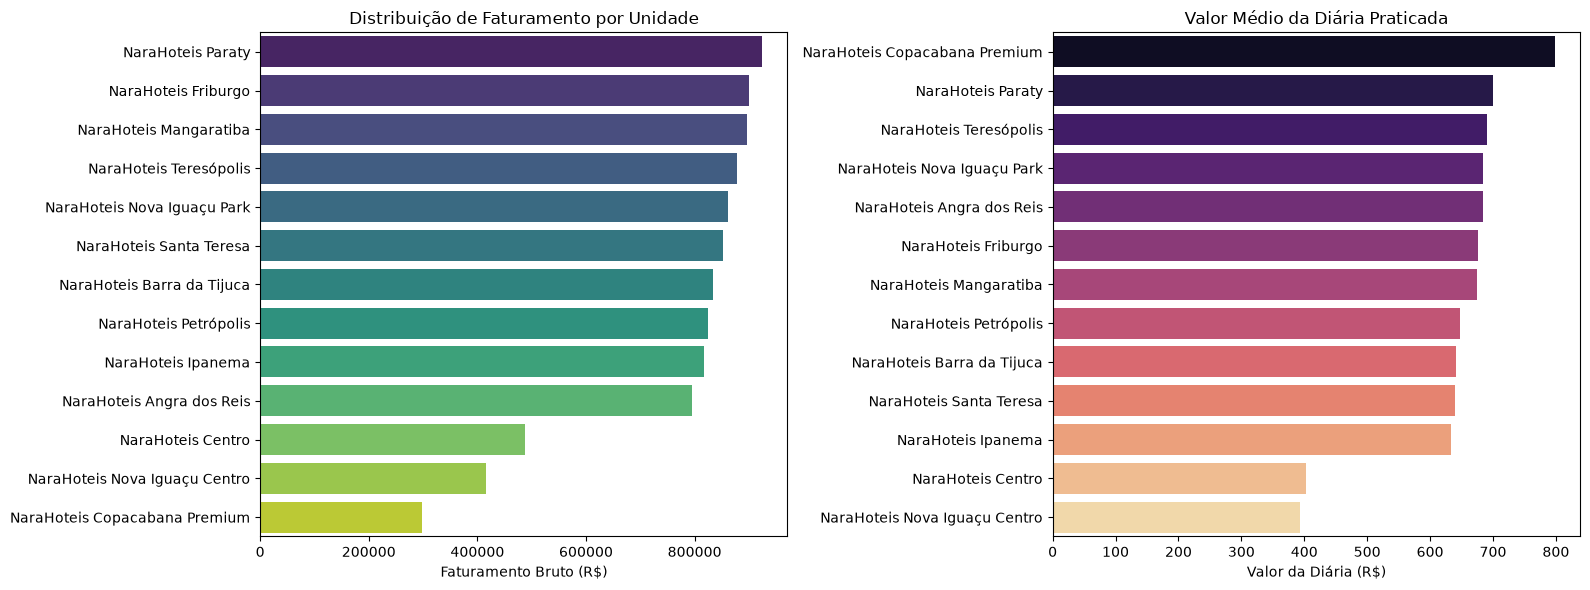

In [22]:
# Painel com 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Faturamento Total
sns.barplot(data=faturamento_unidade, x='faturamento_reserva', y='nome_unidade', ax=axes[0], palette='viridis')
axes[0].set_title('Distribuição de Faturamento por Unidade')
axes[0].set_xlabel('Faturamento Bruto (R$)')
axes[0].set_ylabel('')

# Gráfico 2: Valor Médio da Diária
sns.barplot(data=ticket_medio_unidade, x='valor_diaria_base', y='nome_unidade', ax=axes[1], palette='magma')
axes[1].set_title('Valor Médio da Diária Praticada')
axes[1].set_xlabel('Valor da Diária (R$)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [23]:
# 1. Unindo os dois DataFrames (Faturamento e Diária Média) em uma única tabela
tabela_resumo = faturamento_unidade.merge(ticket_medio_unidade, on='nome_unidade')

# 2. Renomeando as colunas para um formato mais legível para negócios
tabela_resumo.columns = ['Unidade', 'Faturamento Total', 'Diária Média']

# 3. Criando uma função para formatar os valores para o padrão R$ (Moeda Brasileira)
def formatar_moeda(valor):
    # Formata com 2 casas decimais e separador de milhar americano, depois inverte para o padrão BR
    return f"R$ {valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

# 4. Aplicando a formatação nas colunas financeiras
tabela_resumo['Faturamento Total'] = tabela_resumo['Faturamento Total'].apply(formatar_moeda)
tabela_resumo['Diária Média'] = tabela_resumo['Diária Média'].apply(formatar_moeda)

# 5. Exibindo a tabela final formatada
display(tabela_resumo)

,Unidade,Faturamento Total,Diária Média
0,NaraHoteis Paraty,"R$ 924.810,00","R$ 700,43"
1,NaraHoteis Friburgo,"R$ 900.000,00","R$ 675,71"
2,NaraHoteis Mangaratiba,"R$ 897.070,00","R$ 675,34"
3,NaraHoteis Teresópolis,"R$ 877.660,00","R$ 691,03"
4,NaraHoteis Nova Iguaçu Park,"R$ 861.530,00","R$ 684,65"
5,NaraHoteis Santa Teresa,"R$ 852.320,00","R$ 639,39"
6,NaraHoteis Barra da Tijuca,"R$ 833.550,00","R$ 641,77"
7,NaraHoteis Petrópolis,"R$ 824.590,00","R$ 647,26"
8,NaraHoteis Ipanema,"R$ 818.170,00","R$ 634,03"
9,NaraHoteis Angra dos Reis,"R$ 795.700,00","R$ 683,81"


PEGUNTA
A diretoria quer entender o comportamento das diárias praticadas na rede e a distribuição do faturamento entre as unidades. O que os dados revelam?

RESPOSTA 1:

Líderes de Faturamento e Luxo (Eixo Turístico/Serra e Costa Verde):
Unidades como Paraty (Faturamento Total de R$ 924.810,00 e Diária Média de R$ 700,43) e Friburgo (R$ 900.000,00 e R$ 675,71) lideram a rede. Elas provam que o modelo de lazer sustenta o maior volume de receita atrelado a diárias elevadas (acima de R$ 670).

Unidades de Perfil Corporativo/Central (A Queda de Receita):
As filiais Centro (R$ 488.240,00) e Nova Iguaçu Centro (R$ 416.040,00) sofrem uma desvalorização drástica. Embora operem, a diária média despenca para a faixa de R$ 393,00 a R$ 402,00 — praticamente metade do praticado nas unidades de lazer —, puxando o faturamento total para o fundo da tabela.

O Posicionamento de Copacabana Premium:
A nova unidade registra o menor faturamento total da rede (R$ 298.500,00), o que reflete seu período recente de maturação. No entanto, destaca-se por praticar a maior Diária Média de toda a rede (R$ 798,38), validando comercialmente o seu posicionamento 5 estrelas.

Conclusão:
O faturamento da rede está concentrado nas praças de lazer com diárias altas. O principal desafio comercial é reavaliar o modelo de precificação das unidades centrais e acelerar a tração de ocupação da recém-inaugurada Copacabana Premium para capitalizar o seu alto valor de diária.